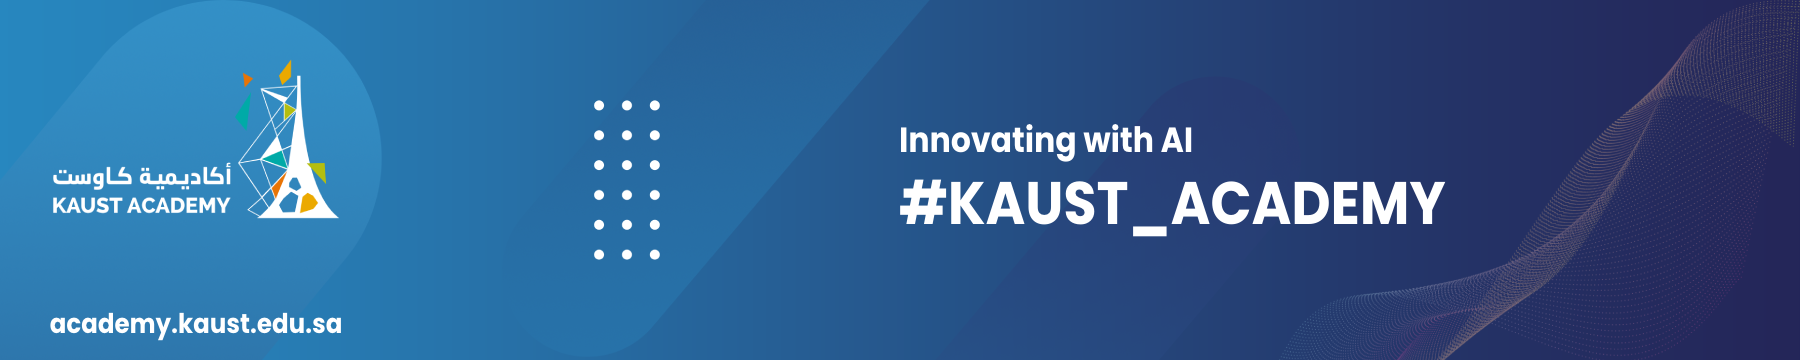

# Recurrent Neural Networks (RNN)
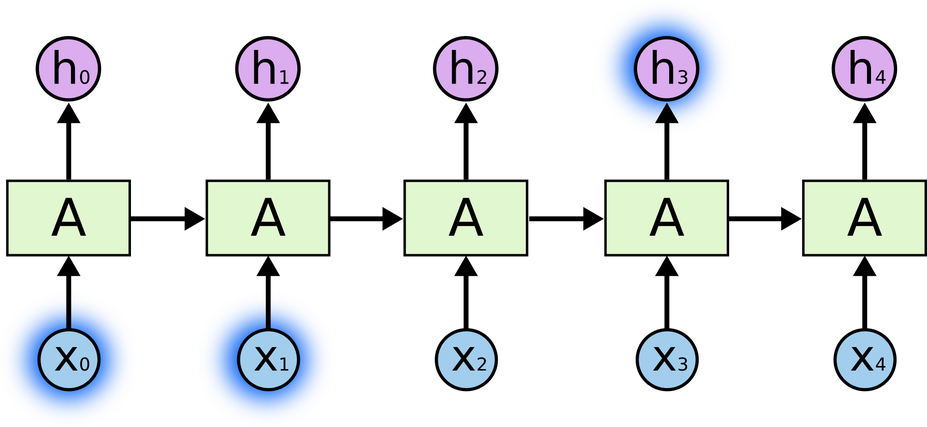

## 1. What is an RNN?

A **Recurrent Neural Network (RNN)** is a neural network designed to work with **sequential data**.

Sequential data means data where the **order matters**.

Examples:

- Text
- Speech
- Time series
- Video frames
- Medical signals
- Captions

In normal neural networks, each input is treated independently.  
In RNNs, the model keeps a **memory** of previous inputs.

---

## 2. Why do we need RNNs?

Some problems depend on previous information.

Example:

```text
I am drinking a cup of ...

## RNN Equation: What Happens Inside `A`

In the RNN diagram, the block `A` represents the RNN cell.

At each time step, the RNN takes:

- the current input: $x_t$
- the previous hidden state: $h_{t-1}$

Then it produces a new hidden state:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

Where:

| Symbol | Meaning |
|---|---|
| $x_t$ | current input |
| $h_{t-1}$ | previous hidden state |
| $W_x$ | weight for the input |
| $W_h$ | weight for the previous hidden state |
| $b$ | bias |
| $\tanh$ | activation function |
| $h_t$ | new hidden state |

---



In [ ]:
!pip install -q kagglehub pandas torch

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

csv_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
import pandas as pd
import os
import re

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


# Review length statistics
df["review_word_count"] = df["review"].apply(lambda x: len(str(x).split()))
df["review_char_count"] = df["review"].apply(lambda x: len(str(x)))

print("\nReview word count statistics:")
print(df["review_word_count"].describe())


Shape: (50000, 2)

Columns:
['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows:
418

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sentiment percentage:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Review word count statistics:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_word_count, dtype: float64


# 1-Preprocessing

In [ ]:
import re
import html
import random
import numpy as np
from collections import Counter

SEED = 42
random.seed(SEED)
df_clean = df.copy()

def clean_text(text):
    text = html.unescape(str(text))             # convert HTML symbols
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags
    text = text.lower()                         # lowercase
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # keep letters only
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

df_clean["review"] = df_clean["review"].apply(clean_text)

In [ ]:
df_clean["label"] = df_clean["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [ ]:

df_clean = df_clean.drop_duplicates(subset=["review", "label"])
df_clean = df_clean.reset_index(drop=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49576 entries, 0 to 49575
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review             49576 non-null  object
 1   sentiment          49576 non-null  object
 2   review_word_count  49576 non-null  int64 
 3   review_char_count  49576 non-null  int64 
 4   label              49576 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.9+ MB


# 2-Train/test split

In [ ]:

MAX_SAMPLES = 8000

df_small = df_clean.sample(
    n=MAX_SAMPLES,
    random_state=SEED
).reset_index(drop=True)

train_ratio = 0.8

train_df = df_small.sample(
    frac=train_ratio,
    random_state=SEED
)

test_df = df_small.drop(train_df.index)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train shape: (6400, 5)
Test shape: (1600, 5)

Train labels:
label
0    3230
1    3170
Name: count, dtype: int64

Test labels:
label
1    842
0    758
Name: count, dtype: int64


# 3-Tokenization and vocabulary

In [ ]:
def tokenize(text):
    return text.split()

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for review in train_df["review"]:
    counter.update(tokenize(review))

MAX_VOCAB_SIZE = 10000

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, count in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

print("\nFirst 20 vocabulary items:")
for i, (word, idx) in enumerate(vocab.items()):
    if i == 20:
        break
    print(word, "->", idx)

Vocabulary size: 10000

First 20 vocabulary items:
<PAD> -> 0
<UNK> -> 1
the -> 2
a -> 3
and -> 4
of -> 5
to -> 6
is -> 7
it -> 8
in -> 9
i -> 10
this -> 11
that -> 12
s -> 13
was -> 14
as -> 15
movie -> 16
for -> 17
with -> 18
but -> 19


# 4-Encode reviews

In [ ]:
MAX_LEN = 200

def encode_review(text, vocab, max_len=MAX_LEN):
    """
    Convert review text into token IDs.
    """
    tokens = tokenize(text)

    ids = [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]


    ids = ids[:max_len]

    return ids

train_encoded = [
    (encode_review(row["review"], vocab), row["label"])
    for _, row in train_df.iterrows()
]

test_encoded = [
    (encode_review(row["review"], vocab), row["label"])
    for _, row in test_df.iterrows()
]

print("Original review:")
print(train_df.loc[0, "review"])

print("\nEncoded review:")
print(train_encoded[0][0][:30])

print("\nLabel:")
print(train_encoded[0][1])

Original review:
what the hell was the point of this dull movie it looked pretty interesting in the beginning but quickly fell flat on its face its supposed to be based on a true story but for crying out loud is there no more script writers left in hollywood man iv e seen these guys in some of the best movies ever made defoe can play just about anything and when i see he s in a movie i don t have a problem renting it but i m starting to wonder redford also a great actor is also slipping perhaps their hard up or just losing their senses the dialog was long and terribly heavy eyed especially at home with the family i wonder if the actors thought they had a hit going here perhaps uh an oscar

Encoded review:
[49, 2, 560, 14, 2, 218, 5, 11, 709, 16, 8, 574, 186, 220, 9, 2, 449, 19, 1000, 1428, 968, 23, 97, 395, 97, 416, 6, 29, 480, 23]

Label:
0


## 5-RNN for Sentiment Classification

Now we will train a simple Recurrent Neural Network on the IMDB reviews.

The RNN reads each review word by word.  
At each time step, it updates its hidden state:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

For sentiment classification, we use the final hidden state to predict:

- `1` = positive review
- `0` = negative review

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class IMDBDataset(Dataset):
    def __init__(self, encoded_data):
        self.encoded_data = encoded_data

    def __len__(self):
        return len(self.encoded_data)

    def __getitem__(self, idx):
        token_ids, label = self.encoded_data[idx]

        token_ids = torch.tensor(token_ids, dtype=torch.long)
        label = torch.tensor(label, dtype=torch.float32)

        return token_ids, label


def collate_batch(batch):
    """
    Pads reviews in the same batch to equal length.
    """
    texts, labels = zip(*batch)

    lengths = torch.tensor(
        [len(text) for text in texts],
        dtype=torch.long
    )

    padded_texts = nn.utils.rnn.pad_sequence(
        texts,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    labels = torch.stack(labels)

    return padded_texts, labels, lengths


BATCH_SIZE = 32

train_loader = DataLoader(
    IMDBDataset(train_encoded),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    IMDBDataset(test_encoded),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Using device: cuda
Number of training batches: 200
Number of testing batches: 50


In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        # text shape: (batch_size, sequence_length)32, dependens on the longest text in batch

        embedded = self.embedding(text)

        # embedded shape: (batch_size, sequence_length, embedding_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, hidden = self.rnn(packed)

        # hidden shape: (num_layers, batch_size, hidden_dim)
        final_hidden = hidden[-1]

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for text, labels, lengths in dataloader:
        text = text.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()


        logits = model(text, lengths)


        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size

        probabilities = torch.sigmoid(logits)
        predictions = probabilities >= 0.5

        correct += (predictions.float() == labels).sum().item()
        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, dataloader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for text, labels, lengths in dataloader:
            text = text.to(device)
            labels = labels.to(device).float()


            logits = model(text, lengths)


            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size


            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= 0.5

            correct += (predictions.float() == labels).sum().item()
            total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 8
LEARNING_RATE = 0.001

rnn_model = RNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=LEARNING_RATE
)

rnn_history = []

print("Training Simple RNN")
print("=" * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        rnn_model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate(
        rnn_model,
        test_loader,
        criterion
    )

    rnn_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Training Simple RNN
Epoch 01 | Train Loss: 0.6947 | Train Acc: 0.5359 | Test Loss: 0.6852 | Test Acc: 0.5525
Epoch 02 | Train Loss: 0.6664 | Train Acc: 0.5911 | Test Loss: 0.6974 | Test Acc: 0.5312
Epoch 03 | Train Loss: 0.6419 | Train Acc: 0.6319 | Test Loss: 0.7018 | Test Acc: 0.5619
Epoch 04 | Train Loss: 0.6004 | Train Acc: 0.6831 | Test Loss: 0.7176 | Test Acc: 0.5656
Epoch 05 | Train Loss: 0.6101 | Train Acc: 0.6653 | Test Loss: 0.7612 | Test Acc: 0.5256
Epoch 06 | Train Loss: 0.5738 | Train Acc: 0.6969 | Test Loss: 0.7446 | Test Acc: 0.5506
Epoch 07 | Train Loss: 0.5180 | Train Acc: 0.7445 | Test Loss: 0.7713 | Test Acc: 0.5694
Epoch 08 | Train Loss: 0.4532 | Train Acc: 0.7917 | Test Loss: 0.7472 | Test Acc: 0.6350


## Long Short-Term Memory (LSTM)

**LSTM**, short for **Long Short-Term Memory**, was introduced by **Sepp Hochreiter and Jürgen Schmidhuber in 1997** to help sequence models learn long-term dependencies.

The key idea of LSTM is that it has a special memory path called the **cell state**.

| Symbol | Meaning                       |
| ------ | ----------------------------- |
| $x_t$  | input at time step $t$        |
| $h_t$  | hidden state / output memory  |
| $c_t$  | cell state / long-term memory |

The cell state $c_t$ allows the model to keep important information for many time steps.

---

## LSTM Gates

LSTM controls memory using three gates:

| Gate        | Purpose                                           |
| ----------- | ------------------------------------------------- |
| Forget gate | Decides what old information should be removed    |
| Input gate  | Decides what new information should be stored     |
| Output gate | Decides what information should be used as output |

The gates are values between 0 and 1.



At each word, the LSTM decides:

1. What should I forget?
2. What should I remember?
3. What should I output?


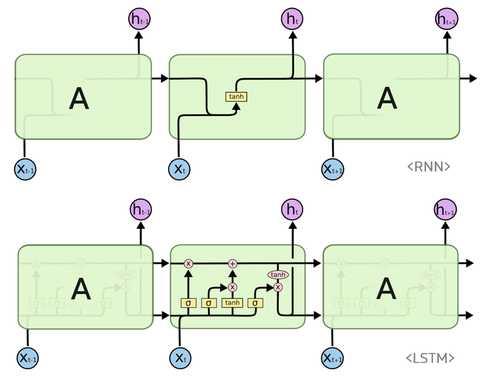

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        # text shape: (batch_size, sequence_length)
        embedded = self.embedding(text)

        # embedded shape: (batch_size, sequence_length, embedding_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed)

        # hidden shape: (num_layers, batch_size, hidden_dim)
        final_hidden = hidden[-1]

        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

In [ ]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 8

lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout_rate=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

lstm_history = []

print("Training LSTM")
print("=" * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        lstm_model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate(
        lstm_model,
        test_loader,
        criterion
    )

    lstm_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Training LSTM
Epoch 01 | Train Loss: 0.6822 | Train Acc: 0.5655 | Test Loss: 0.7189 | Test Acc: 0.5594
Epoch 02 | Train Loss: 0.6638 | Train Acc: 0.6002 | Test Loss: 0.6301 | Test Acc: 0.6538
Epoch 03 | Train Loss: 0.6329 | Train Acc: 0.6489 | Test Loss: 0.6282 | Test Acc: 0.6406
Epoch 04 | Train Loss: 0.5573 | Train Acc: 0.7180 | Test Loss: 0.6224 | Test Acc: 0.6731
Epoch 05 | Train Loss: 0.5115 | Train Acc: 0.7606 | Test Loss: 0.6725 | Test Acc: 0.6069
Epoch 06 | Train Loss: 0.4651 | Train Acc: 0.7823 | Test Loss: 0.5785 | Test Acc: 0.7350
Epoch 07 | Train Loss: 0.3674 | Train Acc: 0.8473 | Test Loss: 0.5332 | Test Acc: 0.7525
Epoch 08 | Train Loss: 0.3230 | Train Acc: 0.8703 | Test Loss: 0.5665 | Test Acc: 0.7619


## GRU: Gated Recurrent Unit

**GRU**, short for **Gated Recurrent Unit**, was introduced by **Cho et al. in 2014** as a simpler gated alternative to LSTM.

GRU is designed for sequential data such as text, speech, time series, and captions. Like LSTM, it helps the model remember useful information from previous time steps, but it uses fewer gates and has a simpler structure.



## GRU Gates

GRU uses two main gates:

| Gate        | Purpose                                     |
| ----------- | ------------------------------------------- |
| Update gate | Decides how much old information to keep    |
| Reset gate  | Decides how much past information to forget |

The gates control how information moves through the model.

```text
0 means: forget or block information
1 means: keep or pass information
```


At each word, the GRU asks:

1. How much old memory should I keep?
2. How much old memory should I reset?
3. What new information should I add?

This allows GRU to remember important information without using as many components as LSTM.

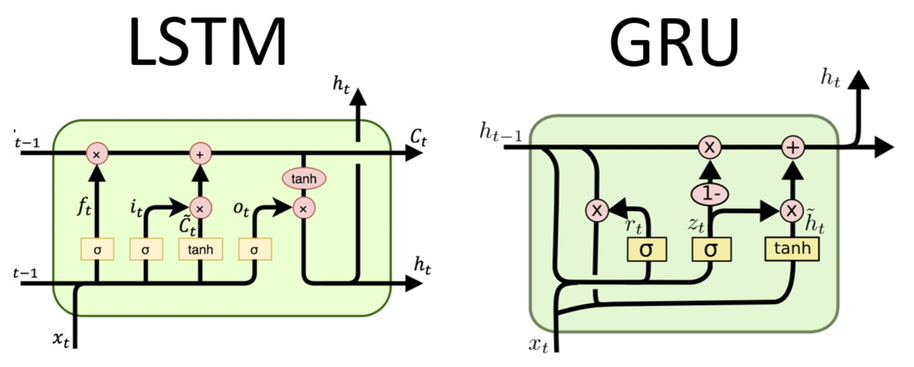

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        # text shape: (batch_size, sequence_length)
        embedded = self.embedding(text)

        # embedded shape: (batch_size, sequence_length, embedding_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, hidden = self.gru(packed)

        # hidden shape: (num_layers, batch_size, hidden_dim)
        final_hidden = hidden[-1]

        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

In [ ]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 8

gru_model = GRUClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout_rate=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

gru_history = []

print("Training GRU")
print("=" * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        gru_model,
        train_loader,
        optimizer,
        criterion
    )

    test_loss, test_acc = evaluate(
        gru_model,
        test_loader,
        criterion
    )

    gru_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Training GRU
Epoch 01 | Train Loss: 0.6816 | Train Acc: 0.5603 | Test Loss: 0.6617 | Test Acc: 0.6119
Epoch 02 | Train Loss: 0.6373 | Train Acc: 0.6411 | Test Loss: 0.6206 | Test Acc: 0.6975
Epoch 03 | Train Loss: 0.5531 | Train Acc: 0.7233 | Test Loss: 0.5565 | Test Acc: 0.7344
Epoch 04 | Train Loss: 0.4649 | Train Acc: 0.7875 | Test Loss: 0.5549 | Test Acc: 0.7438
Epoch 05 | Train Loss: 0.3657 | Train Acc: 0.8512 | Test Loss: 0.4921 | Test Acc: 0.7825
Epoch 06 | Train Loss: 0.2979 | Train Acc: 0.8828 | Test Loss: 0.4934 | Test Acc: 0.7831
Epoch 07 | Train Loss: 0.2296 | Train Acc: 0.9144 | Test Loss: 0.5112 | Test Acc: 0.7963
Epoch 08 | Train Loss: 0.1667 | Train Acc: 0.9414 | Test Loss: 0.6166 | Test Acc: 0.7806


# Student Challenge:

In the previous part of the notebook, we used the IMDB dataset for binary sentiment classification.

Now we will use a different dataset and a different task.

Dataset: **AG News Classification Dataset**

Task: **News topic classification**

The model must classify each news article into one of four classes:

| Label | Class |
|---|---|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Science / Technology |



In [ ]:
!pip install -q kagglehub pandas torch

In [ ]:
import kagglehub
import pandas as pd
import os

DATASET_HANDLE = "amananandrai/ag-news-classification-dataset"

ag_path = kagglehub.dataset_download(DATASET_HANDLE)

print("Dataset downloaded to:")
print(ag_path)

print("\nFiles:")
for root, dirs, files in os.walk(ag_path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Dataset downloaded to:
/kaggle/input/ag-news-classification-dataset

Files:
/kaggle/input/ag-news-classification-dataset/train.csv
/kaggle/input/ag-news-classification-dataset/test.csv


Contributed by: Lama Ayash